## Initialization

In [1]:
from torch.func import vjp
import torch
from torch.func import jacrev, functional_call
import torch.nn as nn
from torch import Tensor

import torch.nn.functional as F

In [2]:
import sys
import os

current_notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root_dir = os.path.abspath(os.path.join(current_notebook_dir, '../../'))

# 将这个父目录添加到sys.path的最前面
if project_root_dir not in sys.path:
    sys.path.insert(0, project_root_dir)

print(sys.path)

['/home/hqdeng7/lijuyang/generalization', '/home/hqdeng7/.conda/envs/ljy/lib/python311.zip', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/lib-dynload', '', '/home/hqdeng7/.conda/envs/ljy/lib/python3.11/site-packages']


In [4]:
import gc, sys, torch, traceback

def recover_cuda_after_oom():
	sys.last_traceback = None
	sys.last_value = None
	sys.last_type = None
	
	gc.collect()
	
	torch.cuda.empty_cache()
	torch.cuda.ipc_collect()
	
	print("✅ CUDA 显存已尝试回收")

# 用法：函数报 OOM 后调用
recover_cuda_after_oom()

✅ CUDA 显存已尝试回收


In [5]:

# def compute_param_gradients(model: nn.Module,
# 									  inputs: torch.Tensor,
# 									  labels: torch.Tensor,
# 									  loss_fn = nn.CrossEntropyLoss(reduction='none'),
# 									  device='cuda'):
# 	"""
# 	Args:
# 		model: PyTorch 模型
# 		inputs: 输入图片，shape=(B,H,W)
# 		labels: 标签
# 		loss_fn: 损失函数, 需要reduction='none'
	
# 	Returns:
# 		grads: 
# 	"""
# 	model.eval()
# 	model.to(device)
# 	inputs, labels = inputs.to(device), labels.to(device)

# 	params = dict(model.named_parameters())
# 	buffers = dict(model.named_buffers())

# 	def compute_losses(params_, inputs_, labels_):
# 		outputs = functional_call(model, (params_, buffers), inputs_)
# 		losses = loss_fn(outputs, labels_)
# 		return losses

# 	grads_per_sample = jacrev(compute_losses, argnums=0)(params, inputs, labels)

# 	return grads_per_sample

import torch
import torch.nn as nn
from torch.func import functional_call, grad, vmap

# 核心功能函数
def compute_param_gradients(model: nn.Module, 
								 inputs: torch.Tensor, 
								 labels: torch.Tensor, 
								 loss_fn = nn.CrossEntropyLoss(reduction='none'), 
								 device='cuda') -> dict:
	"""
	计算每个样本对模型参数的梯度。
	"""
	model.eval()
	model.to(device)
	inputs, labels = inputs.to(device), labels.to(device)

	# 确保损失函数是 reduction='none' 模式
	if loss_fn.reduction != 'none':
		loss_fn = type(loss_fn)(reduction='none')

	params = dict(model.named_parameters())
	buffers = dict(model.named_buffers())

	# 定义一个用于计算单个样本损失的函数
	def single_sample_loss(params_, x, y):
		outputs = functional_call(model, (params_, buffers), x.unsqueeze(0))
		loss = loss_fn(outputs, y.unsqueeze(0))
		return loss.sum() # 确保是标量

	# 获取计算单个样本梯度的函数
	grad_fn = grad(single_sample_loss)

	# 使用 vmap 批量计算每个样本的梯度
	# 为了让cuda不要out of memory, 这里选用vmap而不用jacrev
	grads = vmap(grad_fn, in_dims=(None, 0, 0))(params, inputs, labels)

	return grads

In [6]:
def flatten_grads_dict(grads):
	return torch.cat(tuple(grad.flatten(1) for grad in grads.values()), dim=1)

In [7]:
import heapq
from tqdm import tqdm
from torch.utils.data import DataLoader

@torch.no_grad()
def get_topk_loss_sample(model, ds, loss_fn, k, batch_size=512, device='cuda'):
	dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
	idx_offset = 0

	model.eval()
	model.to(device)
	heap = []
	for inputs, labels in tqdm(dl):
		inputs = inputs.to(device)
		labels = labels.to(device)

		outputs = model(inputs)
		losses = loss_fn(outputs, labels)

		batch_losses = [(loss.item(), idx_offset + j) for j, loss in enumerate(losses)]
		for loss, idx in batch_losses:
			if len(heap) < k:
				heapq.heappush(heap, (loss, idx))
			else:
				heapq.heappushpop(heap, (loss, idx))
		
		idx_offset += len(inputs)

	return sorted(heap, key=lambda x: x[0], reverse=True)

In [8]:
from loss_distribution.pytorch_script.visual_utils \
	import load_cifar10_data, load_model_state_dict

import torchvision
import torchvision.transforms as transforms

In [9]:
data_pth = '/home/hqdeng7/lijuyang/generalization/loss_distribution/pytorch_script/data/cifar10'
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
train_ds = torchvision.datasets.CIFAR10(root=data_pth, train=True, download=True, transform=transform)
test_ds = torchvision.datasets.CIFAR10(root=data_pth, train=False, download=True, transform=transform)

In [10]:
model_path = '/home/hqdeng7/lijuyang/generalization/loss_distribution/model_training_results/cifar10_resnet20/model_200.pth'
model = load_model_state_dict('cifar10', 'resnet20', 10, model_path, 'cuda')

  从字典中提取模型状态字典...
提取成功


In [11]:
train_hloss_samples = get_topk_loss_sample(model, train_ds, nn.CrossEntropyLoss(reduction='none'), 16)
test_hloss_samples = get_topk_loss_sample(model, test_ds, nn.CrossEntropyLoss(reduction='none'), 16)

100%|██████████| 20/20 [00:01<00:00, 11.64it/s]


In [12]:
import torchvision.transforms as T
import numpy as np
from PIL import Image

def inverse_trans_cifar10(tensor_img):
	mean, std = (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
	
	for t, m, s in zip(tensor_img, mean, std):
		t.mul_(s).add_(m)
	tensor_img = torch.clamp(tensor_img, 0, 1)
	
	# 转成numpy数组，shape (H,W,C)
	np_img = tensor_img.mul(255).byte().permute(1, 2, 0).cpu().numpy()
	# 转PIL
	pil_img = Image.fromarray(np_img)
	return pil_img

def img_show(img, ax):
	img_np = np.array(img)
	ax.imshow(img_np)
	ax.axis('off')
	return ax

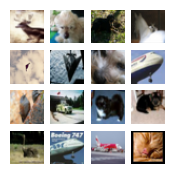

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(2,2))
axes = axes.flatten()

for i in range(16):
	sample_idx = train_hloss_samples[i][1]
	img = inverse_trans_cifar10(train_ds[sample_idx][0])

	img_show(img, ax=axes[i])

## Grad inner prod

In [ ]:
import torch
import heapq
from torch.utils.data import DataLoader

def find_topk_similar_grad_samples(
	model, 
	ref_input, ref_label, 
	target_ds, 
	k=16,
	loss_fn=nn.CrossEntropyLoss(reduction='none'), 
	device='cuda', batch_size=128
):
	
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')

	# 计算参考样本梯度
	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	dataloader = DataLoader(target_ds, batch_size=batch_size, shuffle=False)

	heap = []
	idx_offset = 0
	for inputs, labels in tqdm(dataloader):
		inputs = inputs.to(device)
		labels = labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		grad_inner_prods = grads_flat @ g_ref

		batch_inner_prods = [(prod.item(), idx_offset+i) \
					   for i, prod in enumerate(grad_inner_prods)]

		for prod, idx in batch_inner_prods:
			if len(heap) < k:
				heapq.heappush(heap, (prod, idx))
			else:
				heapq.heappushpop(heap, (prod, idx))
		
		idx_offset += len(inputs)

	heap.sort(key=lambda x: x[0], reverse=True)

	return heap		

In [14]:
sample_loss_rank = 7
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
target_ds = train_ds

sim_samples = find_topk_similar_grad_samples(model, ref_input, ref_label, target_ds, 
												   batch_size=512)

  5%|▌         | 5/98 [00:01<00:19,  4.65it/s]

100%|██████████| 98/98 [00:19<00:00,  4.99it/s]


In [15]:
cifar10_cls = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',     
    'dog', 'frog', 'horse', 'ship', 'truck'
]

@torch.no_grad()
def eval_samples(
	model: nn.Module, inputs: Tensor, labels: Tensor, 
	loss_fn = nn.CrossEntropyLoss(reduction='none'), 
	device='cuda'):

	loss_fn = loss_fn if loss_fn.reduction == 'none' \
					else type(loss_fn)(reduction='none')

	inputs = inputs.to(device)
	labels = labels.to(device)
	model = model.to(device)
	model.eval()

	outputs = model(inputs)
	losses = loss_fn(outputs, labels)
	pred_labels = torch.argmax(outputs, dim=1)

	return losses, pred_labels

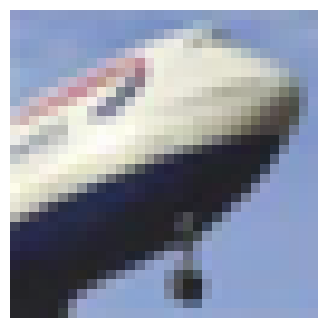

loss: 4.6706    true: airplane    pred: ship
loss: 4.2176    true: airplane    pred: ship
loss: 4.1102    true: airplane    pred: ship
loss: 3.0953    true: airplane    pred: ship
loss: 2.1183    true: airplane    pred: ship
loss: 1.9979    true: airplane    pred: ship
loss: 2.2991    true: airplane    pred: ship
loss: 4.6078    true: truck    pred: ship
loss: 3.0485    true: airplane    pred: truck
loss: 0.7730    true: airplane    pred: ship
loss: 0.9666    true: airplane    pred: ship
loss: 1.1739    true: airplane    pred: ship
loss: 2.8776    true: airplane    pred: cat
loss: 3.1523    true: airplane    pred: ship
loss: 1.9510    true: airplane    pred: ship
loss: 2.2317    true: airplane    pred: ship


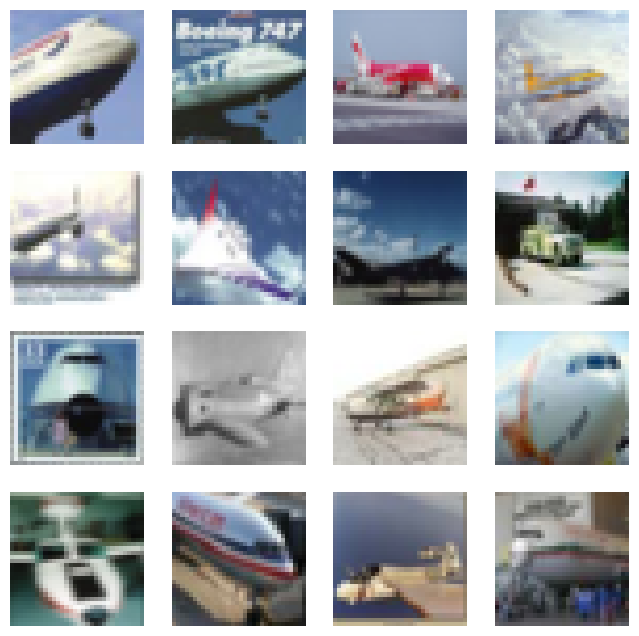

In [ ]:
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]

plt.figure(figsize=(4, 4))
img = inverse_trans_cifar10(ref_input)
plt.imshow(img)
plt.axis('off')
plt.show()


fig, axes = plt.subplots(4, 4, figsize=(8,8))
axes = axes.flatten()
for i in range(16):
	sample_idx = sim_samples[i][1]
	img = inverse_trans_cifar10(train_ds[sample_idx][0])

	img_show(img, ax=axes[i])


# 取出16个样本的 index
sim_sample_indices = [sim_samples[i][1] for i in range(16)]

# 从数据集取出图像和标签
imgs, labels = zip(*[train_ds[idx] for idx in sim_sample_indices])
imgs = torch.stack(imgs)     # shape: (16, C, H, W)
labels = torch.tensor(labels) # shape: (16,)

# 批量评估
losses, pred_labels = eval_samples(model, imgs, labels)

# 打印结果
for i in range(16):
    print(f'loss: {losses[i]:.4f}' +
          f'    true: {cifar10_cls[labels[i].item()]}' +
          f'    pred: {cifar10_cls[pred_labels[i].item()]}')

In [17]:
sim_samples

[(172786.28125, 47215),
 (96351.9765625, 16918),
 (81016.6171875, 41435),
 (78937.953125, 16513),
 (78894.34375, 44749),
 (75813.671875, 32830),
 (60304.30078125, 10394),
 (45811.59765625, 11152),
 (45556.50390625, 19716),
 (45538.21875, 45096),
 (45448.96484375, 3024),
 (44340.87890625, 39774),
 (42501.37109375, 16596),
 (41068.76171875, 43731),
 (40814.5234375, 6098),
 (40211.72265625, 46200)]

### plot_grad_sim

In [56]:
def eval_single(model, input, label : int, device='cuda'):
	# 增加 batch 维度
	input_ = input.unsqueeze(0)   # (1, C, H, W)
	label_ = torch.tensor([label], dtype=torch.long)  # (1,)

	# 调用函数
	loss, pred_label = eval_samples(model, input_, label_, device=device)

	return loss.item(), pred_label.item()


def plot_grad_sim(model, ref_input, ref_label, 
				  target_ds, batch_size=512, device='cuda',
				  sim_function=find_topk_similar_grad_samples,
				  print_sims = False):
	sim_samples = sim_function(model, ref_input, ref_label, target_ds, 
													batch_size=batch_size, device=device)
	if print_sims:
		for i in range(16):
			print(sim_samples[i][0])
	
	loss, pred_label = eval_single(model, ref_input, ref_label, device=device)
	
	# 画出原图
	img = inverse_trans_cifar10(ref_input)
	print(f'loss: {loss:.4f}' + \
		'    true label: ' + cifar10_cls[ref_label] + \
		'    pred label: ' + cifar10_cls[pred_label])
	plt.figure(figsize=(4, 4))
	plt.imshow(img)
	plt.axis('off')
	plt.show()

	# 画出16个sim图
	fig, axes = plt.subplots(4, 4, figsize=(8,8))
	axes = axes.flatten()
	for i in range(16):
		sample_idx = sim_samples[i][1]
		img = inverse_trans_cifar10(target_ds[sample_idx][0])

		img_show(img, ax=axes[i])

	# 打印信息
	sim_sample_indices = [sim_samples[i][1] for i in range(16)]

	imgs, labels = zip(*[target_ds[idx] for idx in sim_sample_indices])
	imgs = torch.stack(imgs)     # shape: (16, C, H, W)
	labels = torch.tensor(labels) # shape: (16,)

	# 批量评估
	losses, pred_labels = eval_samples(model, imgs, labels)

	# 打印结果
	for i in range(16):
		print(f'loss: {losses[i]:.4f}' +
			f'    true: {cifar10_cls[labels[i].item()]}' +
			f'    pred: {cifar10_cls[pred_labels[i].item()]}')


In [ ]:
sample_loss_rank = 0
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
eval_single(model, ref_input, ref_label)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 10
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 10
ref = 'test'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 7
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 7
ref = 'train'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 9
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

In [ ]:
sample_loss_rank = 9
ref = 'test'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]
plot_grad_sim(model, ref_input, ref_label, target_ds)

## Cosine Similarity

In [19]:
def find_topk_gradcos_samples(
	model, 
	ref_input, ref_label, 
	target_ds, 
	k=16,
	loss_fn=nn.CrossEntropyLoss(reduction='none'), 
	device='cuda', batch_size=128
):
	
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')

	# 计算参考样本梯度
	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	dataloader = DataLoader(target_ds, batch_size=batch_size, shuffle=False)

	heap = []
	idx_offset = 0
	for inputs, labels in tqdm(dataloader):
		inputs = inputs.to(device)
		labels = labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		grad_inner_prods = F.cosine_similarity(grads_flat, g_ref.unsqueeze(0), dim=1)

		batch_inner_prods = [(prod.item(), idx_offset+i) \
					   for i, prod in enumerate(grad_inner_prods)]

		for prod, idx in batch_inner_prods:
			if len(heap) < k:
				heapq.heappush(heap, (prod, idx))
			else:
				heapq.heappushpop(heap, (prod, idx))
		
		idx_offset += len(inputs)

	heap.sort(key=lambda x: x[0], reverse=True)

	return heap

In [ ]:
sample_loss_rank = 9
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples)

In [ ]:
train_hloss_samples

In [ ]:
test_hloss_samples

100%|██████████| 98/98 [00:19<00:00,  5.08it/s]

0.9999545812606812
0.4913017749786377
0.4676452875137329
0.4661880433559418
0.44161278009414673
0.4397103190422058
0.4384858012199402
0.436145544052124
0.4247323274612427
0.4237264096736908
0.42182469367980957
0.418956458568573
0.41725367307662964
0.4164908230304718
0.41609883308410645
0.41534584760665894
loss: 7.0716    true label: deer    pred label: cat


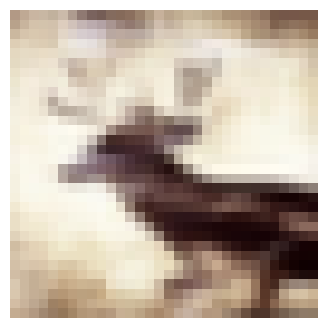

loss: 7.0716    true: deer    pred: cat
loss: 0.0078    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.0579    true: deer    pred: deer
loss: 0.3925    true: deer    pred: deer
loss: 0.3358    true: deer    pred: deer
loss: 0.0872    true: deer    pred: deer
loss: 0.0006    true: deer    pred: deer
loss: 0.0827    true: deer    pred: deer
loss: 2.3578    true: deer    pred: cat
loss: 0.0000    true: deer    pred: deer
loss: 0.0001    true: deer    pred: deer
loss: 0.0478    true: deer    pred: deer
loss: 0.0001    true: deer    pred: deer
loss: 0.0002    true: deer    pred: deer
loss: 0.0001    true: deer    pred: deer


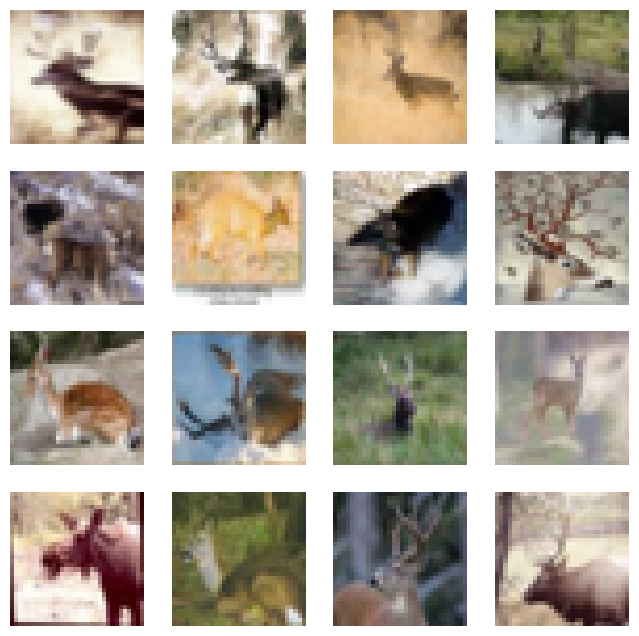

In [132]:
sample_loss_rank = 0
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples, print_sims=True)

In [ ]:
sample_loss_rank = 0
ref = 'train'
target_ds = test_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples)

100%|██████████| 98/98 [00:19<00:00,  5.04it/s]

0.4922485649585724
0.4729355275630951
0.47063812613487244
0.4626433253288269
0.4615776836872101
0.45926791429519653
0.45398181676864624
0.4537810981273651
0.45352256298065186
0.4515456557273865
0.451088011264801
0.45050764083862305
0.44727659225463867
0.4414505362510681
0.44025909900665283
0.43954557180404663
loss: 10.1163    true label: deer    pred label: airplane


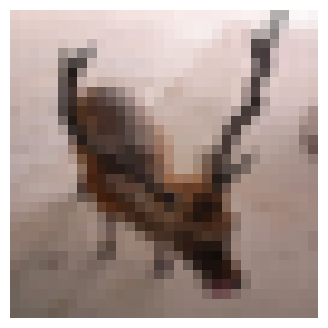

loss: 0.0000    true: deer    pred: deer
loss: 0.0035    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.5151    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.0022    true: deer    pred: deer
loss: -0.0000    true: deer    pred: deer
loss: 0.0119    true: deer    pred: deer
loss: 1.6815    true: deer    pred: airplane
loss: 0.0004    true: deer    pred: deer
loss: 0.0000    true: deer    pred: deer
loss: 0.0247    true: deer    pred: deer
loss: 0.0098    true: deer    pred: deer
loss: 1.0654    true: deer    pred: airplane
loss: 0.0000    true: deer    pred: deer
loss: 1.8673    true: deer    pred: airplane


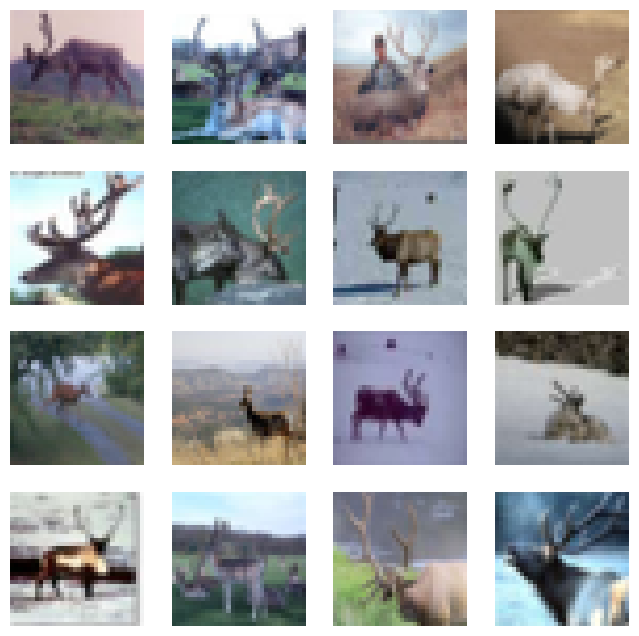

In [131]:
sample_loss_rank = 10
ref = 'test'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples, print_sims=True)

 18%|█▊        | 18/98 [00:03<00:16,  4.98it/s]

100%|██████████| 98/98 [00:19<00:00,  5.03it/s]

0.9998606443405151
0.5627255439758301
0.5094963312149048
0.507805585861206
0.5043403506278992
0.5041483640670776
0.4945623576641083
0.4867432415485382
0.4818933308124542
0.4786610007286072
0.4778340458869934
0.4759601950645447
0.4660806357860565
0.4654883146286011
0.4635762870311737
0.46188753843307495
loss: 4.6706    true label: airplane    pred label: ship


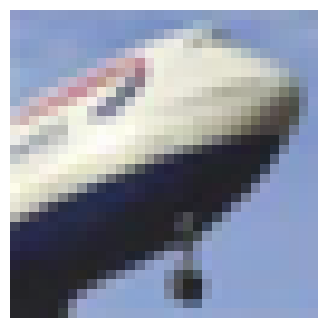

loss: 4.6706    true: airplane    pred: ship
loss: 4.2176    true: airplane    pred: ship
loss: 0.0009    true: airplane    pred: airplane
loss: 0.0389    true: airplane    pred: airplane
loss: 0.0005    true: airplane    pred: airplane
loss: 0.0203    true: airplane    pred: airplane
loss: 0.0080    true: airplane    pred: airplane
loss: 0.0001    true: airplane    pred: airplane
loss: 0.2597    true: airplane    pred: airplane
loss: 0.0307    true: airplane    pred: airplane
loss: 2.1183    true: airplane    pred: ship
loss: 0.0132    true: airplane    pred: airplane
loss: 0.0026    true: airplane    pred: airplane
loss: 0.0033    true: airplane    pred: airplane
loss: 0.0003    true: airplane    pred: airplane
loss: 0.0014    true: airplane    pred: airplane


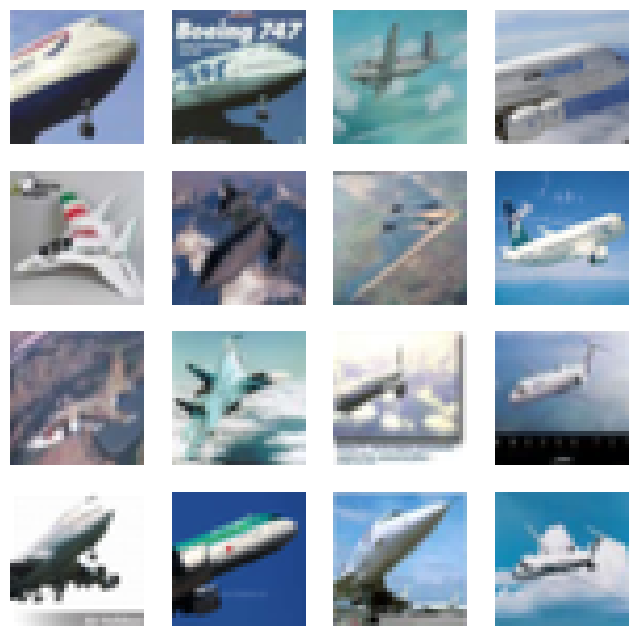

In [22]:
sample_loss_rank = 7
ref = 'train'
target_ds = train_ds

if ref == 'test':
	ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = test_ds[ref_sample_idx]
else:
	ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
	ref_input, ref_label = train_ds[ref_sample_idx]

plot_grad_sim(model, ref_input, ref_label, target_ds, sim_function=find_topk_gradcos_samples, print_sims=True)

## 函数式尝试

In [ ]:
def find_topk_samples(
	ds, 
	fn,
	k=16,
	batch_size=256,
):
	
	dl = DataLoader(ds, batch_size=batch_size, shuffle=False)

	heap = []
	idx_offset = 0
	for batch in tqdm(dl):

		batch_res = fn(batch)
		batch_res_idx = [ (res, idx_offset+i) for i, res in enumerate(batch_res)]

		for res_idx in batch_res_idx:
			if len(heap) < k:
				heapq.heappush(heap, res_idx)
			else:
				heapq.heappushpop(heap, res_idx)
		
		idx_offset += len(batch[0])

	heap.sort(key=lambda x: x[0], reverse=True)

	return heap

In [ ]:
@torch.no_grad()
def get_batch_loss_fn(model, loss_fn=nn.CrossEntropyLoss(reduction='none'), device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)
	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)
		outputs = model(inputs)
		losses =  loss_fn(outputs, labels)
		return losses.detach().cpu().tolist() 
	return f

hloss_test_samples = find_topk_samples(test_ds, get_batch_loss_fn(model), k=128)
print(len(hloss_test_samples))

100%|██████████| 40/40 [00:02<00:00, 17.50it/s]

128


In [48]:
# fig, axes = plt.subplots(16, 8, figsize=(16, 32))
# axes = axes.flatten()

# for i in range(128):
# 	sample_idx = hloss_test_samples[i][1]
# 	img = inverse_trans_cifar10(test_ds[sample_idx][0])

# 	img_show(img, ax=axes[i])

In [ ]:
@torch.no_grad()
def get_batch_grad_prod_fn(model, 
						   ref_input, ref_label,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.to(device).unsqueeze(0)
	ref_label = torch.tensor(ref_label).to(device).unsqueeze(0)

	g_ref_dict = compute_param_gradients(model, ref_input, ref_label, loss_fn, device)
	g_ref = flatten_grads_dict(g_ref_dict)[0]  # shape: [D]

	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)

		grads_dict = compute_param_gradients(model, inputs, labels, loss_fn, device)
		grads_flat = flatten_grads_dict(grads_dict)  # [B, D]

		# 计算与参考样本梯度的内积，shape [B]
		grad_inner_prods = grads_flat @ g_ref
		return grad_inner_prods.detach().cpu().tolist() 
	return f

In [ ]:
sample_loss_rank = 7
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_grad_prod_fn(model, ref_input, ref_label)

sim_samples = find_topk_samples(target_ds, f, batch_size=512)

 12%|█▏        | 12/98 [00:02<00:16,  5.10it/s]

100%|██████████| 98/98 [00:19<00:00,  4.91it/s]


In [70]:
def plot_topk_info( target_ds, fn, 
			   batch_size=512, device='cuda', print_sims = False):
	sim_samples = find_topk_samples(target_ds, fn, k = 16, batch_size = batch_size)
	
	if print_sims:
		for i in range(16):
			print(sim_samples[i][0])
	
	loss, pred_label = eval_single(model, ref_input, ref_label, device=device)
	
	# 画出原图
	img = inverse_trans_cifar10(ref_input)
	print(f'loss: {loss:.4f}' + \
		'    true label: ' + cifar10_cls[ref_label] + \
		'    pred label: ' + cifar10_cls[pred_label])
	plt.figure(figsize=(4, 4))
	plt.imshow(img)
	plt.axis('off')
	plt.show()

	# 画出16个sim图
	fig, axes = plt.subplots(4, 4, figsize=(8,8))
	axes = axes.flatten()
	for i in range(16):
		sample_idx = sim_samples[i][1]
		img = inverse_trans_cifar10(target_ds[sample_idx][0])

		img_show(img, ax=axes[i])

	# 打印信息
	sim_sample_indices = [sim_samples[i][1] for i in range(16)]

	imgs, labels = zip(*[target_ds[idx] for idx in sim_sample_indices])
	imgs = torch.stack(imgs)     # shape: (16, C, H, W)
	labels = torch.tensor(labels) # shape: (16,)

	# 批量评估
	losses, pred_labels = eval_samples(model, imgs, labels)

	# 打印结果
	for i in range(16):
		print(f'loss: {losses[i]:.4f}' +
			f'    true: {cifar10_cls[labels[i].item()]}' +
			f'    pred: {cifar10_cls[pred_labels[i].item()]}')


In [ ]:
def compute_batch_logits(model, params, buffers, inputs):
	return functional_call(model, (params, buffers), inputs)

# def get_param_jac(model: nn.Module, inputs: Tensor):
# 	"""
# 	返回形状: (batch_size, output_dim, total_params)
# 	"""
# 	params, buffers = dict(model.named_parameters()), dict(model.named_buffers())
# 	param_jacob = jacrev(compute_batch_logits, argnums=1)(model, params, buffers, inputs)

# 	# 预先分配一个 list 收集 view，避免 tuple 展开占内存
# 	jacob_views = []
# 	for jacob in param_jacob.values():
# 		# 直接 reshape 避免多余 copy
# 		jacob_views.append(jacob.reshape(jacob.shape[0], jacob.shape[1], -1))
	
# 	return torch.cat(jacob_views, dim=2)


# def get_entk(model, inputs0, input1):
# 	"""
# 	返回 K(x_batch, x_single)，形状: (B0, out_dim, out_dim)
# 	"""
# 	jacob0 = get_param_jac(model, inputs0)  # (B0, out_dim, P)
# 	input1 = input1.unsqueeze(0)
# 	jacob1 = get_param_jac(model, input1)   # (1, out_dim, P)

# 	entk = torch.einsum('bop,1qp->boq', jacob0, jacob1)

# 	return entk


def get_param_jac(model: nn.Module, inputs: Tensor):
    """
    返回形状: (batch_size, output_dim, total_params)
    使用 vmap+jacrev 降低显存占用
    """
    params, buffers = dict(model.named_parameters()), dict(model.named_buffers())

    # 单样本 Jacobian
    def single_jac(x):
        jacs = jacrev(compute_batch_logits, argnums=1)(model, params, buffers, x.unsqueeze(0))
        # 拼接到一个 tensor
        jacob_views = [jac.reshape(1, jac.shape[1], -1) for jac in jacs.values()]
        return torch.cat(jacob_views, dim=2)  # (1, out_dim, P)

    # vmap 按 batch 并行
    jacob_all = vmap(single_jac)(inputs)  # (B, 1, out_dim, P)
    jacob_all = jacob_all.squeeze(1)      # (B, out_dim, P)

    return jacob_all

In [ ]:
def get_batch_entkFnorm_fn(model, 
						   ref_input,
						   loss_fn=nn.CrossEntropyLoss(reduction='none'), 
						   device='cuda'):
	model.eval()
	loss_fn = loss_fn if loss_fn.reduction == 'none' else type(loss_fn)(reduction='none')
	model = model.to(device)

	ref_input = ref_input.to(device).unsqueeze(0)

	ref_jacob = get_param_jac(model, ref_input)   # (1, out_dim, P)
	
	def f(batch):
		inputs, labels = batch
		inputs, labels = inputs.to(device), labels.to(device)

		jacobs = get_param_jac(model, inputs)
		entk = torch.einsum('bop,aqp->boq', jacobs, ref_jacob)
		
		return torch.linalg.norm(entk, ord='fro', dim=(1, 2))
	return f

In [81]:
sample_loss_rank = 7
ref_sample_idx = train_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = train_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_entkFnorm_fn(model, ref_input)

100%|██████████| 6250/6250 [03:00<00:00, 34.71it/s]

loss: 4.6706    true label: airplane    pred label: ship


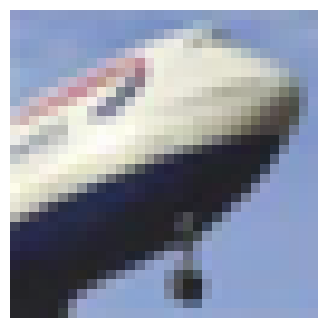

loss: 4.6706    true: airplane    pred: ship
loss: 4.2176    true: airplane    pred: ship
loss: 0.0072    true: ship    pred: ship
loss: 0.0001    true: ship    pred: ship
loss: 0.0001    true: ship    pred: ship
loss: 0.0002    true: ship    pred: ship
loss: 0.0010    true: ship    pred: ship
loss: 0.0002    true: airplane    pred: airplane
loss: -0.0000    true: ship    pred: ship
loss: -0.0000    true: ship    pred: ship
loss: 0.0000    true: ship    pred: ship
loss: 0.0006    true: ship    pred: ship
loss: 0.0004    true: ship    pred: ship
loss: 0.0000    true: ship    pred: ship
loss: 0.0000    true: ship    pred: ship
loss: 0.0004    true: ship    pred: ship


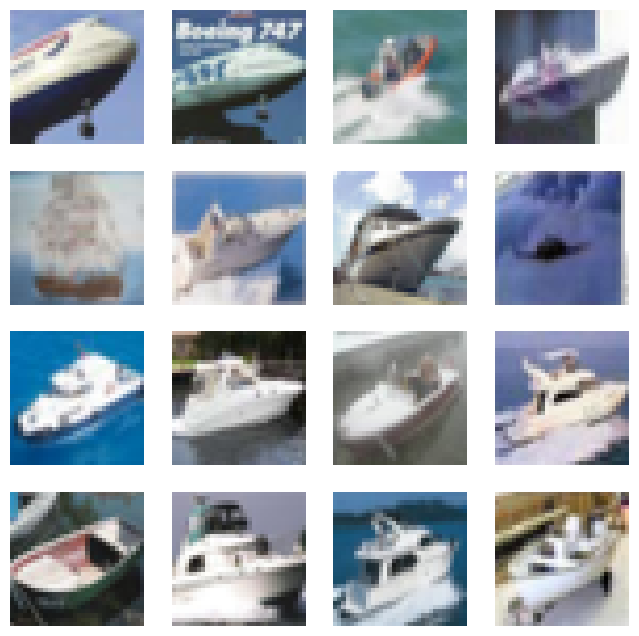

In [96]:
plot_topk_info(target_ds, f, batch_size=8)

In [97]:
import gc
gc.collect()

22812

In [98]:
torch.cuda.empty_cache()

In [93]:
del ref_jacob

NameError: name 'ref_jacob' is not defined

100%|██████████| 6250/6250 [03:05<00:00, 33.62it/s]


loss: 10.1163    true label: deer    pred label: airplane


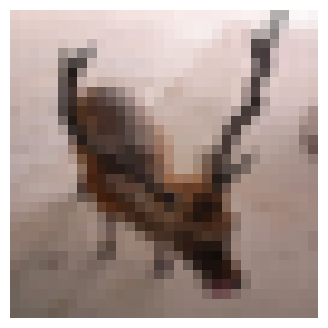

loss: 0.0216    true: airplane    pred: airplane
loss: 0.0004    true: airplane    pred: airplane
loss: 0.2409    true: airplane    pred: airplane
loss: 0.0129    true: airplane    pred: airplane
loss: 0.0151    true: airplane    pred: airplane
loss: 0.0013    true: airplane    pred: airplane
loss: 0.0175    true: airplane    pred: airplane
loss: 0.0001    true: airplane    pred: airplane
loss: 0.0009    true: airplane    pred: airplane
loss: -0.0000    true: deer    pred: deer
loss: 0.0399    true: deer    pred: deer
loss: 0.0025    true: airplane    pred: airplane
loss: 0.0001    true: airplane    pred: airplane
loss: 0.0086    true: bird    pred: bird
loss: 0.0007    true: airplane    pred: airplane
loss: 0.0042    true: truck    pred: truck


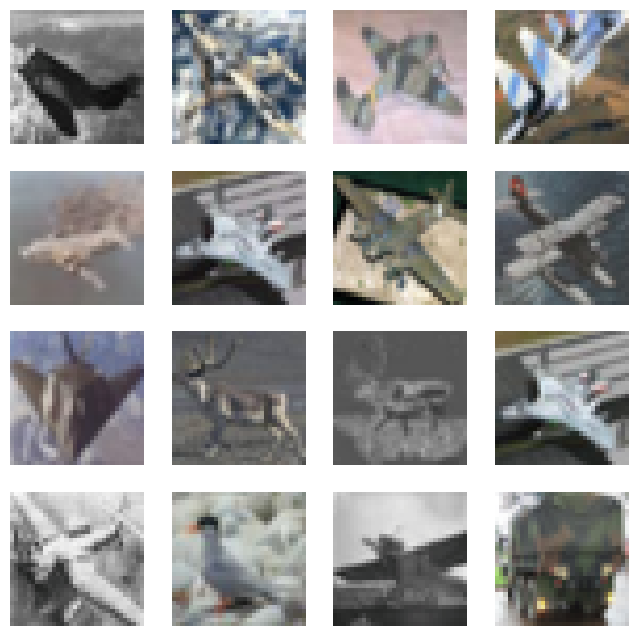

In [99]:
sample_loss_rank = 10
ref_sample_idx = test_hloss_samples[sample_loss_rank][1]
ref_input, ref_label = test_ds[ref_sample_idx]
target_ds = train_ds

f = get_batch_entkFnorm_fn(model, ref_input)
plot_topk_info(target_ds, f, batch_size=8)